In [1]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, permutation_test_score, cross_val_predict
from sklearn.metrics import (make_scorer, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             classification_report)
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler

In [2]:
# -------------------------------------------------------------------
# Load feature matrix
# -------------------------------------------------------------------
df = pd.read_excel(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/feat_table.xlsx", sheet_name='all_feats_500ns',
    index_col="ID"
)

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# -------------------------------------------------------------------
# Features and labels
# -------------------------------------------------------------------
# features above 0.02 mean decrease in impurity only
# feature_cols = [
#     "Gate mean (A)", "Gate SD (A)",
#     "Intermediate %",
#     "R_62", "R_163", "R_164", "R_122", "R_83", "R_89", "R_87", "R_159", "R_160", "R_59", "R_116", "R_115", "R_58", 
#     "Lb7a5 mean (A)"
# ]

# feature_cols = [
#     "Gate mean (A)",
#     "Latch mean (A)",
#     "Gate-latch mean (A)",
#     "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
#     "R_58", "R_59", "R_62",	"R_83",	"R_87",	"R_88",	"R_89",	"R_92",	"R_110", "R_115", "R_116", "R_117", "R_120", "R_122", "R_159",
#     "R_160", "R_163","R_164"
# ]

# all feats
feature_cols = [
    "Gate mean (A)",       "Gate SD (A)",
    # "Latch mean (A)",      "Latch SD (A)",
    # "Lb7a5 mean (A)",      "Lb7a5 SD (A)",
    # "Recoil mean (A)",     "Recoil SD (A)",
    # "Gate-latch mean (A)", "Gate-latch SD (A)",
    # "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
    # "R_58", "R_59", "R_62",	"R_83",	"R_87",	"R_88",	"R_89",	"R_92",	"R_110", "R_115", "R_116", "R_117", "R_120", "R_122", "R_159",
    # "R_160", "R_163","R_164",
    "D_58","W_58","D_59","W_59","D_62","W_62","D_83","W_83","D_87","W_87",
    "D_88","W_88","D_89","W_89","D_92","W_92","D_110","W_110","D_115","W_115",
    "D_116","W_116","D_117","W_117","D_120","W_120","D_122","W_122","D_159","W_159",
    "D_160","W_160","D_163","W_163","D_164","W_164",
    "mean_n_polar",	"std_n_polar", "mean_n_pos_charged", "std_n_pos_charged", "mean_n_neg_charged",	"std_n_neg_charged",
    "Y23 RMSF (A)",	"R79 RMSF (A)",	"I110 RMSF (A)", "G163 RMSF (A)"
]

# All non-NAN residues
#   "D_30","W_30","D_32","W_32","D_33","W_33","D_34","W_34","D_36","W_36","D_46","W_46","D_48","W_48","D_49","W_49","D_50",
#     "W_50","D_51","W_51","D_52","W_52","D_53","W_53","D_54","W_54","D_55","W_55","D_56","W_56","D_57","W_57","D_58","W_58",
#     "D_59","W_59","D_60","W_60","D_61","W_61","D_62","W_62","D_64","W_64","D_65","W_65","D_66","W_66","D_67","W_67","D_71",
#     "W_71","D_73","W_73","D_76","W_76","D_77","W_77","D_78","W_78","D_79","W_79","D_80","W_80","D_81","W_81","D_82","W_82",
#     "D_83","W_83","D_84","W_84","D_85","W_85","D_86","W_86","D_87","W_87","D_88","W_88","D_89","W_89","D_90","W_90","D_91",
#     "W_91","D_92","W_92","D_93","W_93","D_94","W_94","D_95","W_95","D_96","W_96","D_97","W_97","D_98","W_98","D_99","W_99",
#     "D_105","W_105","D_106","W_106","D_107","W_107","D_108","W_108","D_109","W_109","D_110","W_110","D_111","W_111","D_112",
#     "W_112","D_113","W_113","D_114","W_114","D_115","W_115","D_116","W_116","D_117","W_117","D_118","W_118","D_119","W_119",
#     "D_120","W_120","D_121","W_121","D_122","W_122","D_123","W_123","D_124","W_124","D_125","W_125","D_126","W_126","D_139",
#     "W_139","D_140","W_140","D_141","W_141","D_142","W_142","D_143","W_143","D_144","W_144","D_145","W_145","D_146","W_146",
#     "D_147","W_147","D_148","W_148","D_149","W_149","D_150","W_150","D_151","W_151","D_152","W_152","D_154","W_154","D_155",
#     "W_155","D_156","W_156","D_157","W_157","D_158","W_158","D_159","W_159","D_160","W_160","D_161","W_161","D_162","W_162",
#     "D_163","W_163","D_164","W_164","D_165","W_165","D_166","W_166","D_167","W_167","D_168","W_168","D_169","W_169","D_170",
#     "W_170","D_171","W_171","D_173","W_173","D_174","W_174"

# Pocket residues only
    # "D_58","W_58","D_59","W_59","D_62","W_62","D_83","W_83","D_87","W_87",
    # "D_88","W_88","D_89","W_89","D_92","W_92","D_110","W_110","D_115","W_115",
    # "D_116","W_116","D_117","W_117","D_120","W_120","D_122","W_122","D_159","W_159",
    # "D_160","W_160","D_163","W_163","D_164","W_164",

Total samples: 191  |  Binders: 52  |  Nonbinders: 139
Number of features: 48

Structural features (kept unconditionally) : 0
Contact features (subject to variance filter): 48

Variance summary across 48 contact features (StandardScaler):
  Min    : 0.014390
  Median : 0.062435
  Mean   : 0.059392
  Max    : 0.109516
  Features below threshold 0.1 : 46
  Features below threshold 0.05 : 17
  Features below threshold 0.01: 0


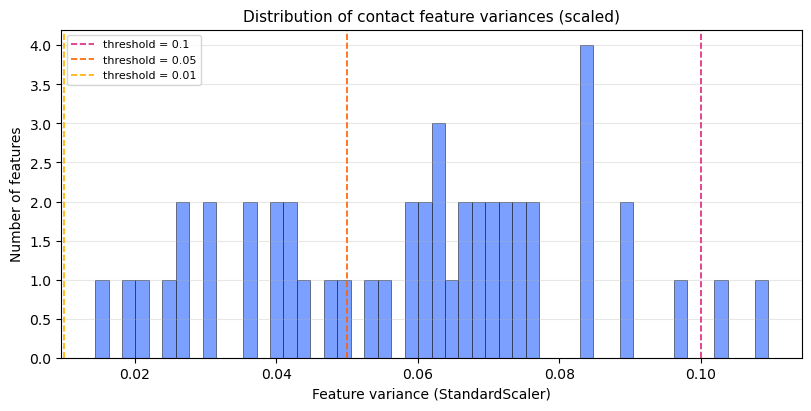


Selected Threshold: 0.05
Contact features kept  : 31 of 48
Contact features dropped: 17
Dropped: ['Gate mean (A)', 'Gate SD (A)', 'W_62', 'W_83', 'D_87', 'W_87', 'D_89', 'W_89', 'D_116', 'W_160', 'mean_n_polar', 'std_n_polar', 'mean_n_pos_charged', 'std_n_pos_charged', 'R79 RMSF (A)', 'I110 RMSF (A)', 'G163 RMSF (A)']

Final feature set: 31 total
  Structural : 0
  Contact    : 31


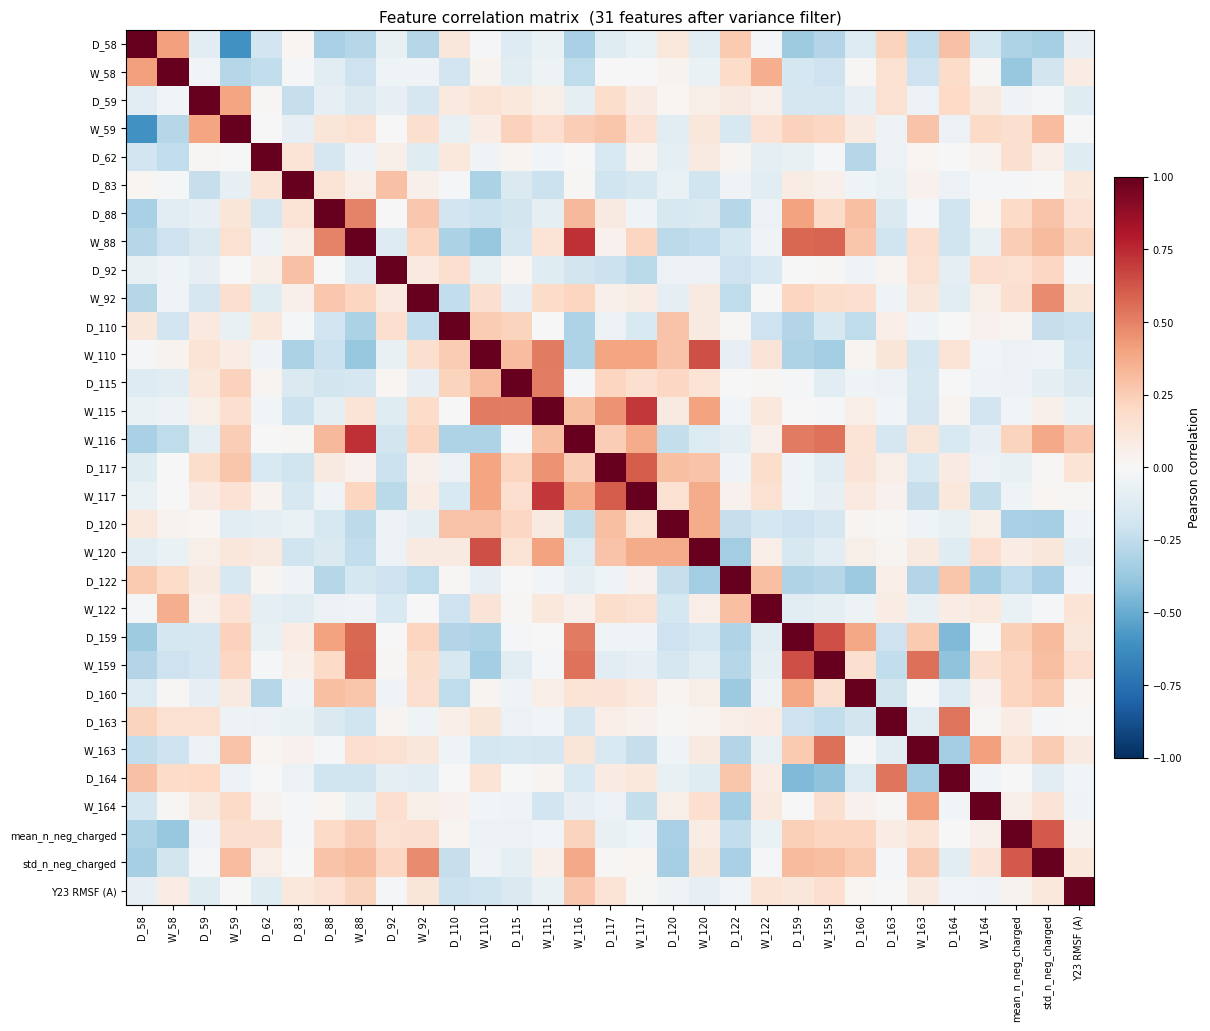

In [3]:
X = df[feature_cols].values
y = df["Label"].values

n_binders    = y.sum()
n_nonbinders = (y == 0).sum()
print(f"Total samples: {len(y)}  |  Binders: {n_binders}  |  Nonbinders: {n_nonbinders}")
print(f"Number of features: {len(feature_cols)}")

# ── Split features into structural (always kept) and contact (filtered) ────────
structural_cols = [
    # "Gate mean (A)",       "Gate SD (A)",
    # "Latch mean (A)",      "Latch SD (A)",
    # "Lb7a5 mean (A)",      "Lb7a5 SD (A)",
    # "Recoil mean (A)",     "Recoil SD (A)",
    # "Gate-latch mean (A)", "Gate-latch SD (A)",
    # "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
    # "mean_n_polar",	"std_n_polar"
]
contact_cols = [c for c in feature_cols if c not in structural_cols]

print(f"\nStructural features (kept unconditionally) : {len(structural_cols)}")
print(f"Contact features (subject to variance filter): {len(contact_cols)}")

# ── Scale ALL features to zero mean, unit variance before variance analysis ────
# StandardScaler makes structural (Å, %) and contact (D/W, 0-1) features
# comparable; post-scaling variance reflects true spread, not unit differences.
scaler        = MinMaxScaler()
X_all         = df[feature_cols].values
X_all_scaled  = scaler.fit_transform(X_all)
X_scaled_df   = pd.DataFrame(X_all_scaled, columns=feature_cols)

# ── Variance summary on scaled contact features ────────────────────────────────
X_contact_scaled = X_scaled_df[contact_cols].values
X_cont_scaled_df = X_scaled_df[contact_cols]
variances        = X_cont_scaled_df.var()

thresh1 = 0.01
thresh2 = 0.05
thresh3 = 0.10

print(f"\nVariance summary across {len(contact_cols)} contact features (StandardScaler):")
print(f"  Min    : {variances.min():.6f}")
print(f"  Median : {variances.median():.6f}")
print(f"  Mean   : {variances.mean():.6f}")
print(f"  Max    : {variances.max():.6f}")
print(f"  Features below threshold {thresh3} : {(variances < thresh3).sum()}")
print(f"  Features below threshold {thresh2} : {(variances < thresh2).sum()}")
print(f"  Features below threshold {thresh1}: {(variances < thresh1).sum()}")

# Plot variance distribution for scaled contact features
fig_var, ax_var = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax_var.hist(variances, bins=50, color='#648FFF', edgecolor='k', linewidth=0.4, alpha=0.85)
ax_var.axvline(thresh3, color='#DC267F', linestyle='--', linewidth=1.2, label=f'threshold = {thresh3}')
ax_var.axvline(thresh2, color='#FE6100', linestyle='--', linewidth=1.2, label=f'threshold = {thresh2}')
ax_var.axvline(thresh1, color='#FFB000', linestyle='--', linewidth=1.2, label=f'threshold = {thresh1}')
ax_var.set_xlabel('Feature variance (StandardScaler)', fontsize=10)
ax_var.set_ylabel('Number of features', fontsize=10)
ax_var.set_title('Distribution of contact feature variances (scaled)', fontsize=11)
ax_var.legend(fontsize=8)
ax_var.grid(True, alpha=0.3, axis='y')
#fig_var.savefig(os.path.join(path, "ML", 'feature_variance_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Apply variance threshold to scaled contact features only ───────────────────
threshold = thresh2
selector      = VarianceThreshold(threshold=threshold)
selector.fit(X_contact_scaled)
kept_contact  = [contact_cols[i] for i in selector.get_support(indices=True)]
dropped_cols  = [contact_cols[i] for i in range(len(contact_cols))
                 if i not in selector.get_support(indices=True)]

print(f"\nSelected Threshold: {threshold}")
print(f"Contact features kept  : {len(kept_contact)} of {len(contact_cols)}")
print(f"Contact features dropped: {len(dropped_cols)}")
print(f"Dropped: {dropped_cols}")

# ── Combine structural + filtered contact features; use scaled values ──────────
final_cols = structural_cols + kept_contact
X          = X_scaled_df[final_cols].values   # scaled throughout

print(f"\nFinal feature set: {len(final_cols)} total")
print(f"  Structural : {len(structural_cols)}")
print(f"  Contact    : {len(kept_contact)}")

# ── Save kept feature list ─────────────────────────────────────────────────────
kept_df = pd.DataFrame({'feature': final_cols})
# kept_df.to_csv(os.path.join(path, 'kept_features.csv'), index=False)

# ── Correlation matrix ─────────────────────────────────────────────────────────
X_filt_df   = pd.DataFrame(X, columns=final_cols)
corr_matrix = X_filt_df.corr()

n  = len(final_cols)
fs = max(12, n * 0.18)

fig, ax = plt.subplots(figsize=(fs, fs * 0.85), constrained_layout=True)
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(final_cols, rotation=90, fontsize=max(4, 7 - n // 40))
ax.set_yticklabels(final_cols, fontsize=max(4, 7 - n // 40))
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Pearson correlation', fontsize=9)
cbar.ax.tick_params(labelsize=7)
ax.set_title(f'Feature correlation matrix  ({n} features after variance filter)', fontsize=11)
#fig.savefig(os.path.join(path, "ML", 'filt_feature_correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# # -------------------- Apply variance filter on DW feats only --------------------
# X = df[feature_cols].values
# y = df["Label"].values

# n_binders    = y.sum()
# n_nonbinders = (y == 0).sum()
# print(f"Total samples: {len(y)}  |  Binders: {n_binders}  |  Nonbinders: {n_nonbinders}")
# print(f"Number of features: {len(feature_cols)}")

# # ── Split features into structural (always kept) and contact (filtered) ────────
# structural_cols = [
#     "Gate mean (A)",       "Gate SD (A)",
#     "Latch mean (A)",      "Latch SD (A)",
#     "Lb7a5 mean (A)",      "Lb7a5 SD (A)",
#     "Recoil mean (A)",     "Recoil SD (A)",
#     "Gate-latch mean (A)", "Gate-latch SD (A)",
#     "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
#     "mean_n_polar",	"std_n_polar"
# ]
# contact_cols = [c for c in feature_cols if c not in structural_cols]

# print(f"\nStructural features (kept unconditionally) : {len(structural_cols)}")
# print(f"Contact features (subject to variance filter): {len(contact_cols)}")

# # ── Variance summary on raw contact features ───────────────────────────────────
# # D, W, R features are already on a comparable 0-1 scale so no scaling needed.
# # Structural features are excluded — they are on different scales (Å, %)
# # and are always informative by design.
# X_contact = df[contact_cols].values
# X_cont_df = pd.DataFrame(X_contact, columns=contact_cols)
# variances = X_cont_df.var()

# thresh1=0.001
# thresh2=0.01
# thresh3=0.05

# print(f"\nVariance summary across {len(contact_cols)} contact features (unscaled):")
# print(f"  Min    : {variances.min():.6f}")
# print(f"  Median : {variances.median():.6f}")
# print(f"  Mean   : {variances.mean():.6f}")
# print(f"  Max    : {variances.max():.6f}")
# print(f"  Features below threshold {thresh3} : {(variances < thresh3).sum()}")
# print(f"  Features below threshold {thresh2} : {(variances < thresh2).sum()}")
# print(f"  Features below threshold {thresh1}: {(variances < thresh1).sum()}")

# # Plot variance distribution for contact features only
# fig_var, ax_var = plt.subplots(figsize=(8, 4), constrained_layout=True)
# ax_var.hist(variances, bins=50, color='#648FFF', edgecolor='k',linewidth=0.4, alpha=0.85)
# ax_var.axvline(thresh3, color='#DC267F', linestyle='--', linewidth=1.2, label=f'threshold = {thresh3}')
# ax_var.axvline(thresh2, color='#FE6100', linestyle='--', linewidth=1.2, label=f'threshold = {thresh2}')
# ax_var.axvline(thresh1, color='#FFB000', linestyle='--', linewidth=1.2, label=f'threshold = {thresh1}')
# ax_var.set_xlabel('Feature variance (unscaled, D/W features)', fontsize=10)
# ax_var.set_ylabel('Number of features', fontsize=10)
# ax_var.set_title('Distribution of contact feature variances', fontsize=11)
# ax_var.legend(fontsize=8)
# ax_var.grid(True, alpha=0.3, axis='y')
# fig_var.savefig(os.path.join(path, "ML", 'feature_variance_distribution.png'), dpi=300, bbox_inches='tight')
# plt.show()

# # print("\nLowest variance contact features (most likely to be dropped):")
# # print(variances.nsmallest(10).to_string())
# # print("\nHighest variance contact features:")
# # print(variances.nlargest(10).to_string())

# # ── Apply variance threshold to contact features only ─────────────────────────
# threshold=thresh2
# selector      = VarianceThreshold(threshold=threshold)
# selector.fit(X_contact)
# kept_contact  = [contact_cols[i] for i in selector.get_support(indices=True)]
# dropped_cols  = [contact_cols[i] for i in range(len(contact_cols))
#                  if i not in selector.get_support(indices=True)]

# print(f"\nSelected Threshold: {threshold}")
# print(f"Contact features kept  : {len(kept_contact)} of {len(contact_cols)}")
# print(f"Contact features dropped: {len(dropped_cols)}")
# print(f"Dropped: {dropped_cols}")

# # ── Combine structural + filtered contact features ────────────────────────────
# final_cols = structural_cols + kept_contact
# X = df[final_cols].values

# print(f"\nFinal feature set: {len(final_cols)} total")
# print(f"  Structural : {len(structural_cols)}")
# print(f"  Contact    : {len(kept_contact)}")

# # ── Save kept feature list ────────────────────────────────────────────────────
# kept_df = pd.DataFrame({'feature': final_cols})
# # kept_df.to_csv(os.path.join(path, 'kept_features.csv'), index=False)

# # ── Correlation matrix ────────────────────────────────────────────────────────
# X_filt_df   = pd.DataFrame(X, columns=final_cols)
# corr_matrix = X_filt_df.corr()

# n  = len(final_cols)
# fs = max(12, n * 0.18)

# fig, ax = plt.subplots(figsize=(fs, fs * 0.85), constrained_layout=True)
# im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
# ax.set_xticks(range(n))
# ax.set_yticks(range(n))
# ax.set_xticklabels(final_cols, rotation=90, fontsize=max(4, 7 - n // 40))
# ax.set_yticklabels(final_cols, fontsize=max(4, 7 - n // 40))
# cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
# cbar.set_label('Pearson correlation', fontsize=9)
# cbar.ax.tick_params(labelsize=7)
# ax.set_title(f'Feature correlation matrix  ({n} features after variance filter)',
#              fontsize=11)
# fig.savefig(os.path.join(path, "ML", 'all_DW_feature_correlation_matrix.png'),
#             dpi=300, bbox_inches='tight')
# plt.show()

## Binary Classficiation
Testing the Random Forest as a 2-class model: **Binder**, **Nonbinder**.

In [5]:

N_SPLITS = 7
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"\n--- Fold composition (n_splits={N_SPLITS}) ---")
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    n_b_train  = y[train_idx].sum()
    n_b_test   = y[test_idx].sum()
    n_nb_train = (y[train_idx] == 0).sum()
    n_nb_test  = (y[test_idx]  == 0).sum()
    print(f"  Fold {fold+1}: train = {n_b_train} binders / {n_nb_train} nonbinders  |  "
          f"test = {n_b_test} binders / {n_nb_test} nonbinders")


rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
)

# -------------------------------------------------------------------
# Stratified cross-validation
# -------------------------------------------------------------------
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "f1":                make_scorer(f1_score,        zero_division=0),
    "precision":         make_scorer(precision_score, zero_division=0),
    "recall":            make_scorer(recall_score,    zero_division=0),
}

cv_results = cross_validate(
    rf, X, y, cv=cv,
    scoring=scoring,
    return_train_score=False,
)

metrics = {k.replace("test_", ""): v for k, v in cv_results.items()
           if k.startswith("test_")}

print(f"\n--- {N_SPLITS}-fold stratified CV (balanced RF) ---")
metrics_df = pd.DataFrame({
    k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
    for k, v in metrics.items()
}).T
print(metrics_df.to_string())

# -------------------------------------------------------------------
# Permutation test
# -------------------------------------------------------------------
score, perm_scores, pval = permutation_test_score(
    rf, X, y, cv=cv, scoring="balanced_accuracy",
    n_permutations=100, random_state=42, n_jobs=1,
)
print(f"\nPermutation test  |  Observed balanced accuracy: {score:.3f}  |  p-value: {pval:.3f}")

# -------------------------------------------------------------------
# Fit on full dataset for importance
# -------------------------------------------------------------------
rf.fit(X, y)
y_pred = rf.predict(X)
y_prob = rf.predict_proba(X)[:, 1]


--- Fold composition (n_splits=7) ---
  Fold 1: train = 44 binders / 119 nonbinders  |  test = 8 binders / 20 nonbinders
  Fold 2: train = 44 binders / 119 nonbinders  |  test = 8 binders / 20 nonbinders
  Fold 3: train = 44 binders / 120 nonbinders  |  test = 8 binders / 19 nonbinders
  Fold 4: train = 45 binders / 119 nonbinders  |  test = 7 binders / 20 nonbinders
  Fold 5: train = 45 binders / 119 nonbinders  |  test = 7 binders / 20 nonbinders
  Fold 6: train = 45 binders / 119 nonbinders  |  test = 7 binders / 20 nonbinders
  Fold 7: train = 45 binders / 119 nonbinders  |  test = 7 binders / 20 nonbinders

--- 7-fold stratified CV (balanced RF) ---
                    Mean     SD
accuracy           0.842  0.048
balanced_accuracy  0.740  0.089
roc_auc            0.869  0.037
f1                 0.622  0.178
precision          0.823  0.176
recall             0.515  0.175

Permutation test  |  Observed balanced accuracy: 0.740  |  p-value: 0.010


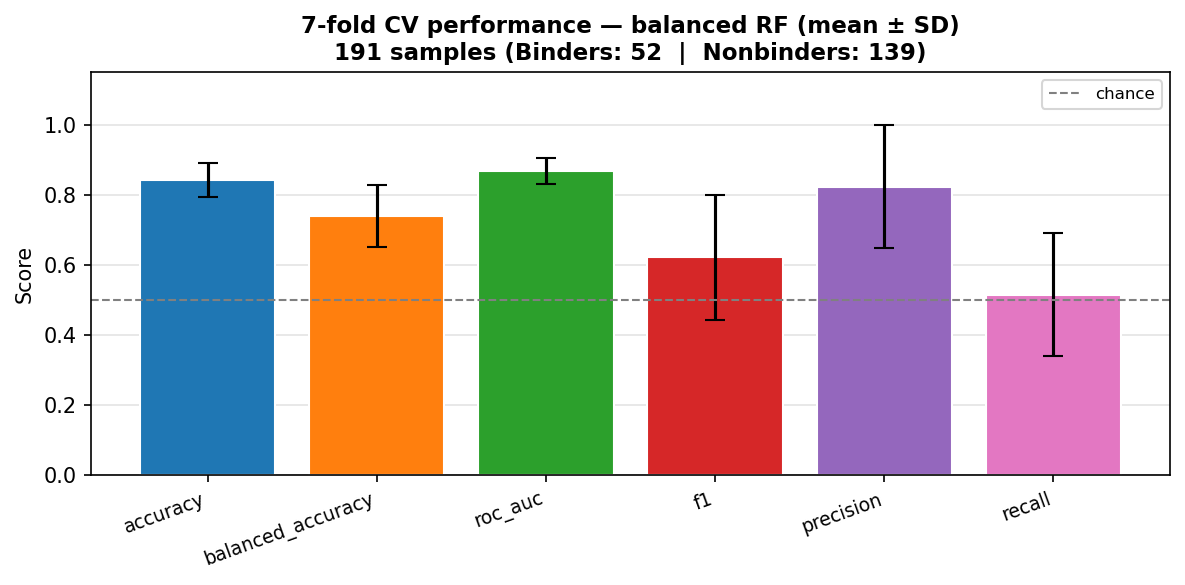

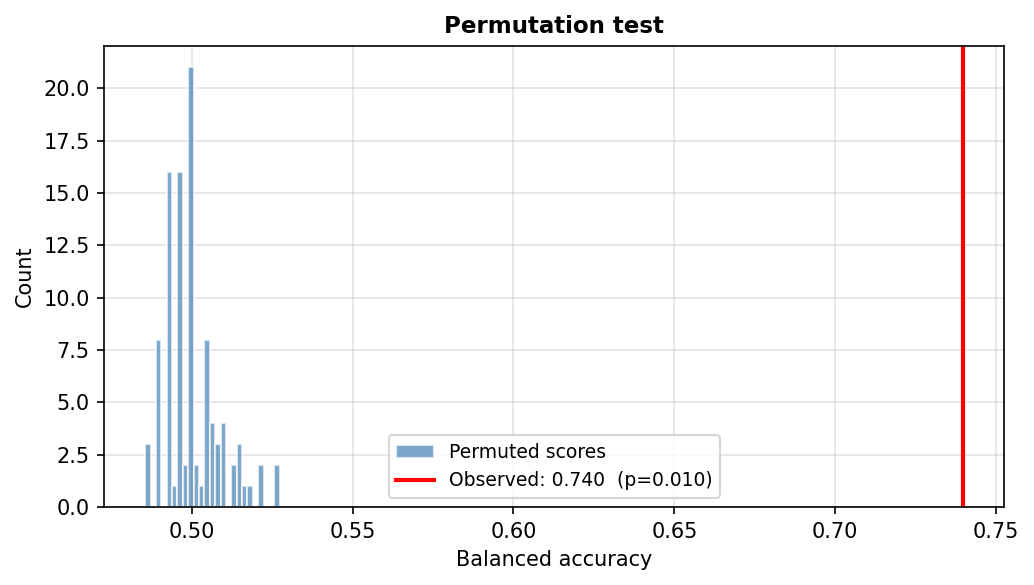

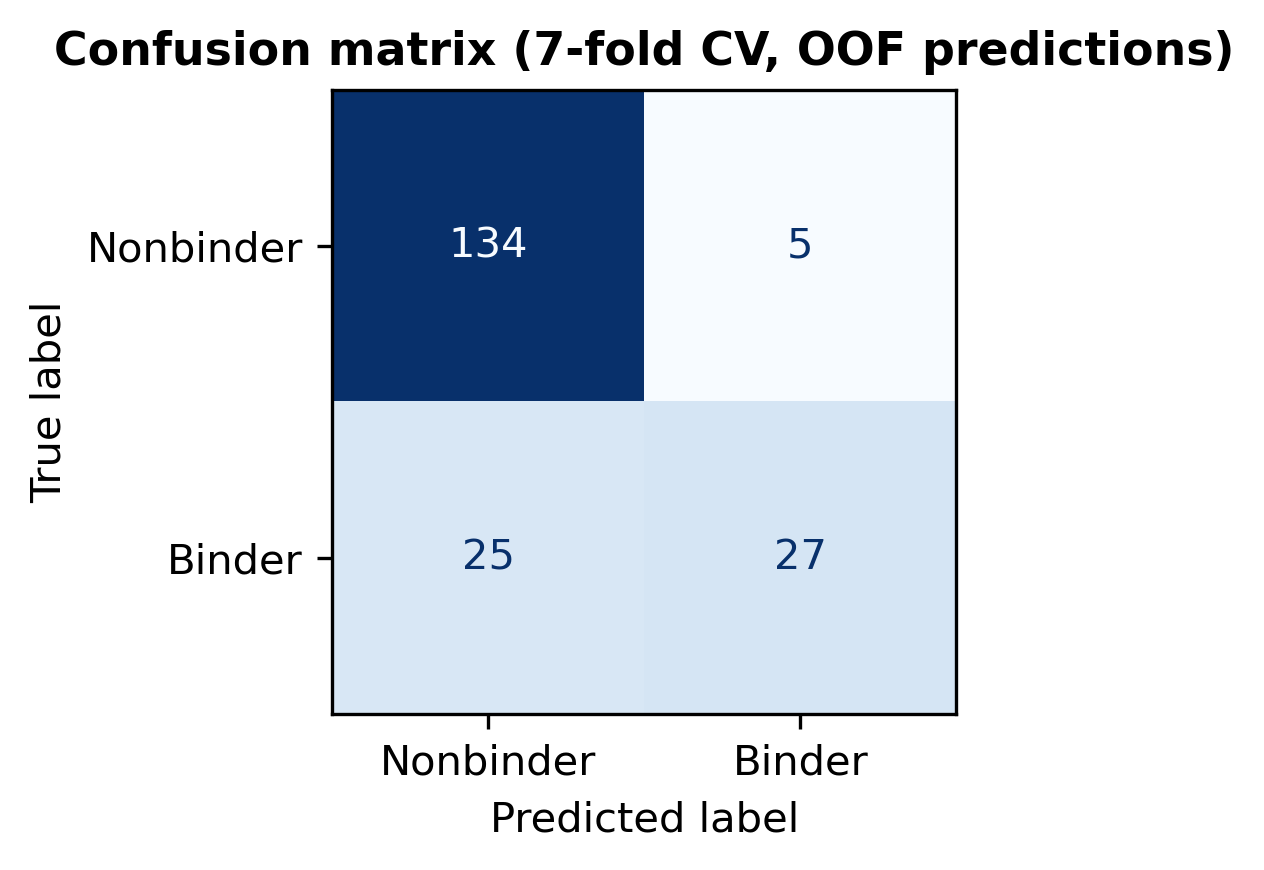

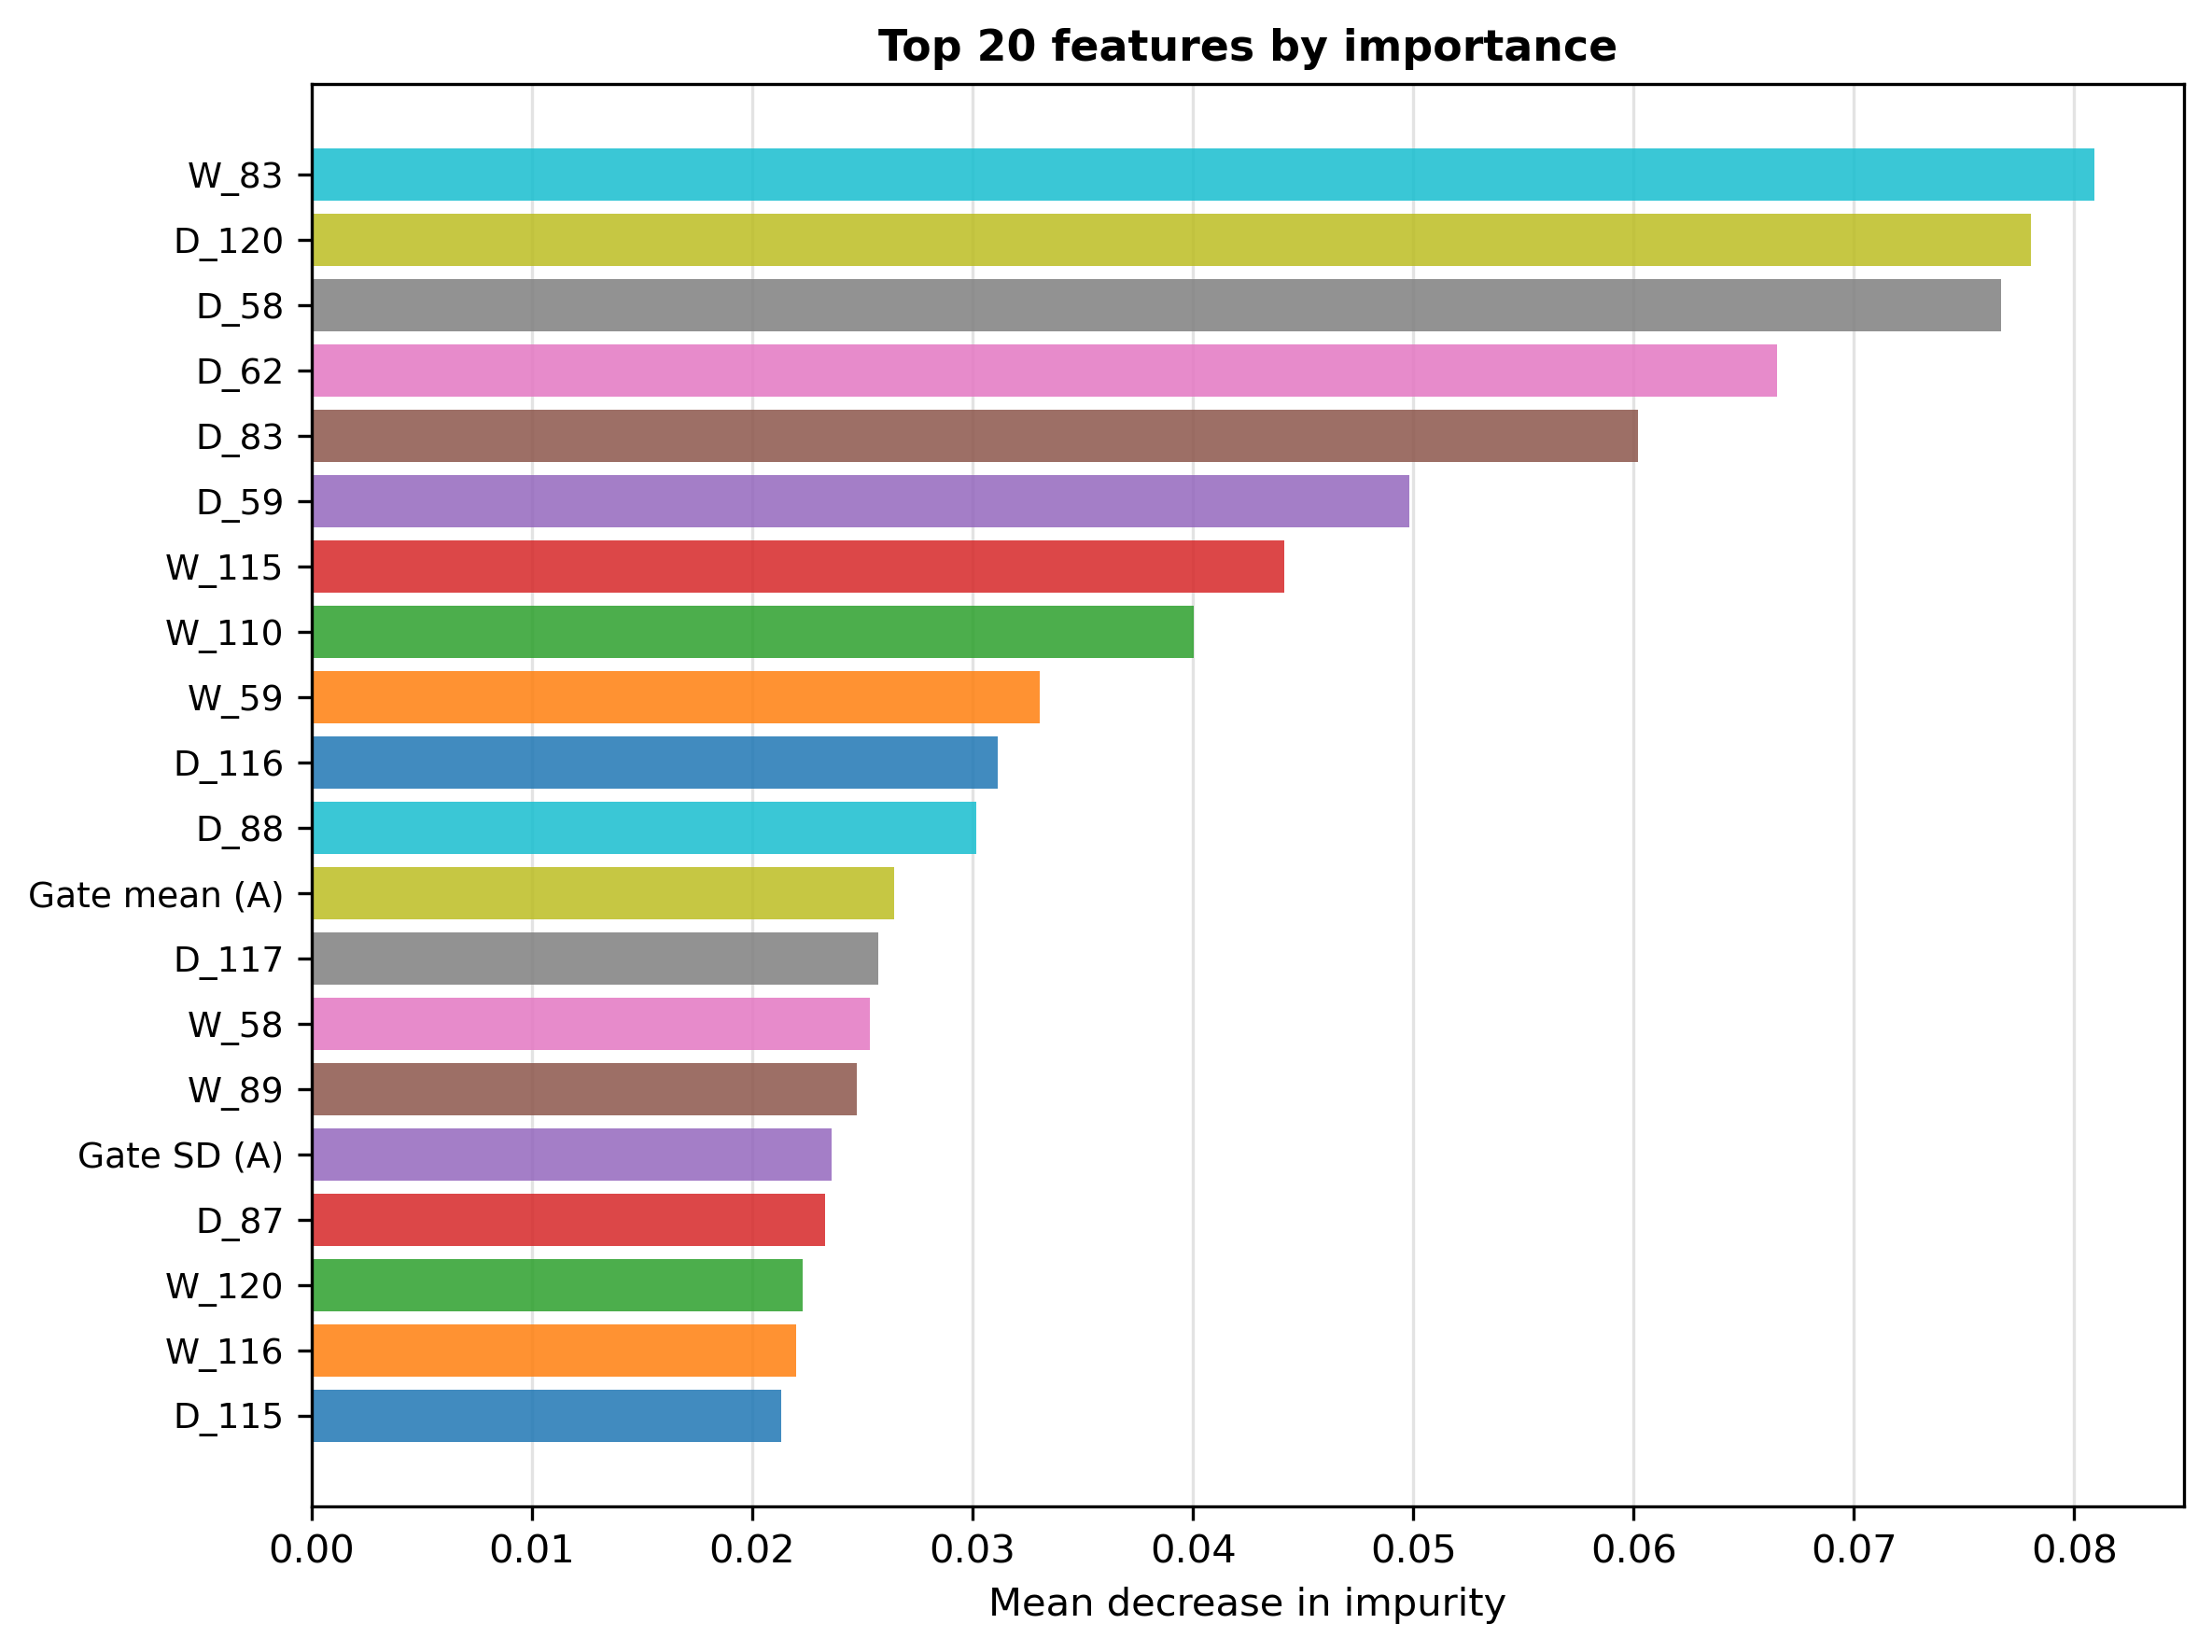

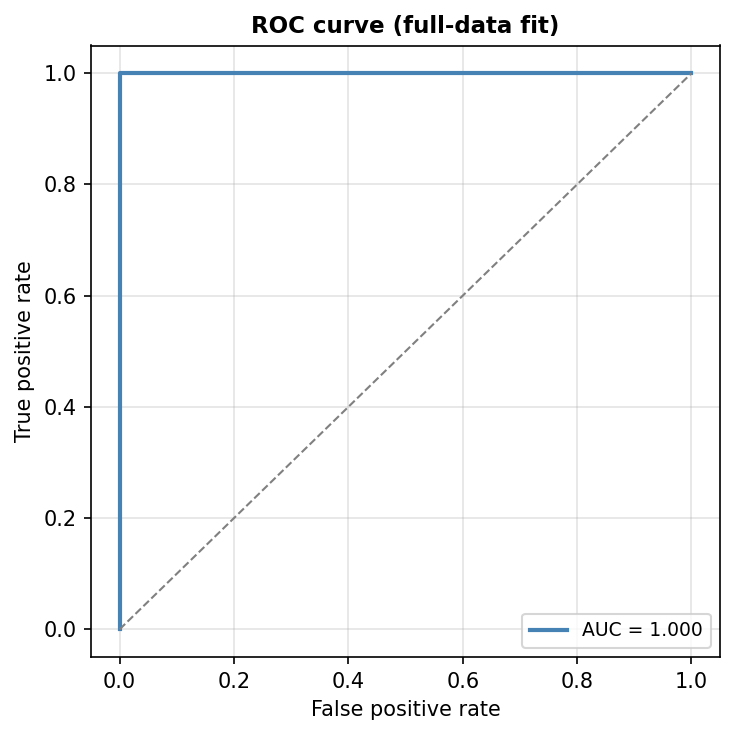


--- Classification report (7-fold CV, OOF predictions) ---
              precision    recall  f1-score   support

   Nonbinder       0.84      0.96      0.90       139
      Binder       0.84      0.52      0.64        52

    accuracy                           0.84       191
   macro avg       0.84      0.74      0.77       191
weighted avg       0.84      0.84      0.83       191


--- Incorrectly predicted sequences (30 total) ---
          seq_id true_label predicted_label     error_type
    seq17_binder     Binder       Nonbinder False Negative
 bind_083_binder     Binder       Nonbinder False Negative
 bind_101_binder     Binder       Nonbinder False Negative
 bind_102_binder     Binder       Nonbinder False Negative
 bind_022_binder     Binder       Nonbinder False Negative
 bind_088_binder     Binder       Nonbinder False Negative
 bind_020_binder     Binder       Nonbinder False Negative
 bind_034_binder     Binder       Nonbinder False Negative
 bind_110_binder     Binder   

In [6]:
# -------------------------------------------------------------------
# Figure 1: CV metric summary
# -------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 4), dpi=150)
metric_names = list(metrics.keys())
means = [metrics[m].mean() for m in metric_names]
sds   = [metrics[m].std()  for m in metric_names]
x     = np.arange(len(metric_names))

ax1.bar(x, means, yerr=sds, capsize=5,
        color=plt.get_cmap("tab10")(np.linspace(0, 0.6, len(metric_names))),
        edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Score", fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.axhline(0.5, color="gray", linestyle="--", lw=1, label="chance")
ax1.set_title(f"{N_SPLITS}-fold CV performance — balanced RF (mean ± SD)\n{len(y)} samples (Binders: {n_binders}  |  Nonbinders: {n_nonbinders})",
              fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, axis="y", alpha=0.35)
ax1.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 2: permutation test
# -------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=150)
ax2.hist(perm_scores, bins=25, color="steelblue", alpha=0.7, edgecolor="white",
         label="Permuted scores")
ax2.axvline(score, color="red", lw=2, label=f"Observed: {score:.3f}  (p={pval:.3f})")
ax2.set_xlabel("Balanced accuracy", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.set_title("Permutation test", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35)
ax2.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 3: confusion matrix
# -------------------------------------------------------------------
y_pred_cv = cross_val_predict(rf, X, y, cv=cv)   # OOF predictions
fig3, ax3 = plt.subplots(figsize=(7, 3), dpi=300)
cm_mat = confusion_matrix(y, y_pred_cv)
disp   = ConfusionMatrixDisplay(cm_mat, display_labels=["Nonbinder", "Binder"])
disp.plot(ax=ax3, colorbar=False, cmap="Blues")
ax3.set_title(f"Confusion matrix ({N_SPLITS}-fold CV, OOF predictions)", fontsize=11, fontweight="bold")
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 4: feature importances
# -------------------------------------------------------------------
mdi_imp  = rf.feature_importances_
perm_imp = permutation_importance(rf, X, y, n_repeats=30, random_state=42, n_jobs=1)

# ── Set how many top features to display ─────────────────────────────────────
TOP_N = 20

sorted_idx      = np.argsort(mdi_imp)[-TOP_N:]
feat_names      = [feature_cols[i] for i in sorted_idx]
perm_sorted_idx = np.argsort(perm_imp.importances_mean)[-TOP_N:]
feat_names_perm = [feature_cols[i] for i in perm_sorted_idx]

prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [prop_cycle[i % len(prop_cycle)] for i in range(len(sorted_idx))]

fig4, axes4 = plt.subplots(figsize=(8, 6), dpi=300)

axes4.barh(range(len(sorted_idx)), mdi_imp[sorted_idx],
           color=colors, alpha=0.85)
axes4.set_yticks(range(len(sorted_idx)))
axes4.set_yticklabels(feat_names, fontsize=9)
axes4.set_xlabel("Mean decrease in impurity", fontsize=10)
axes4.set_title(f"Top {TOP_N} features by importance", fontsize=11, fontweight="bold")
axes4.grid(True, axis="x", alpha=0.35)
axes4.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 5: ROC curve
# -------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc      = auc(fpr, tpr)

fig5, ax5 = plt.subplots(figsize=(5, 5), dpi=150)
ax5.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {roc_auc:.3f}")
ax5.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax5.set_xlabel("False positive rate", fontsize=10)
ax5.set_ylabel("True positive rate", fontsize=10)
ax5.set_title("ROC curve (full-data fit)", fontsize=11, fontweight="bold")
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.35)
ax5.set_axisbelow(True)
plt.tight_layout()

plt.show()

# -------------------------------------------------------------------
# Classification report + incorrect predictions
# -------------------------------------------------------------------
seq_ids = df["name"].tolist()   # ← add this; assumes dataframe is named df

print(f"\n--- Classification report ({N_SPLITS}-fold CV, OOF predictions) ---")
print(classification_report(y, y_pred_cv, target_names=["Nonbinder", "Binder"],
                             zero_division=0))

wrong_mask = y_pred_cv != y
wrong_df   = pd.DataFrame({
    "seq_id":          [seq_ids[i] for i in np.where(wrong_mask)[0]],
    "true_label":      ["Binder" if y[i] == 1 else "Nonbinder"
                        for i in np.where(wrong_mask)[0]],
    "predicted_label": ["Binder" if y_pred_cv[i] == 1 else "Nonbinder"
                        for i in np.where(wrong_mask)[0]],
    "error_type":      ["False Negative" if y[i] == 1 else "False Positive"
                        for i in np.where(wrong_mask)[0]],
}).sort_values("error_type").reset_index(drop=True)

print(f"\n--- Incorrectly predicted sequences ({len(wrong_df)} total) ---")
print(wrong_df.to_string(index=False))

fn = wrong_df[wrong_df["error_type"] == "False Negative"]
fp = wrong_df[wrong_df["error_type"] == "False Positive"]
print(f"\n  False Negatives (binders predicted as nonbinder): {len(fn)}")
for _, row in fn.iterrows():
    print(f"    {row['seq_id']}")
print(f"\n  False Positives (nonbinders predicted as binder): {len(fp)}")
for _, row in fp.iterrows():
    print(f"    {row['seq_id']}")

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
# fig1.savefig(os.path.join(path, "ML", f"250ns_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")
# fig3.savefig(os.path.join(path, "ML", f"250ns_RF_confusion_matrix_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")
# fig4.savefig(os.path.join(path, "ML", f"250ns_RF_feat_importance_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")

fig1.savefig(os.path.join(path, "ML", f"filt_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")
fig3.savefig(os.path.join(path, "ML", f"filt_RF_confusion_matrix_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")
fig4.savefig(os.path.join(path, "ML", f"filt_RF_feat_importance_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")

# fig1.savefig(os.path.join(path, "ML", f"all_feats_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")
# fig3.savefig(os.path.join(path, "ML", f"all_feats_RF_confusion_matrix_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")
# fig4.savefig(os.path.join(path, "ML", f"all_feats_RF_feat_importance_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")

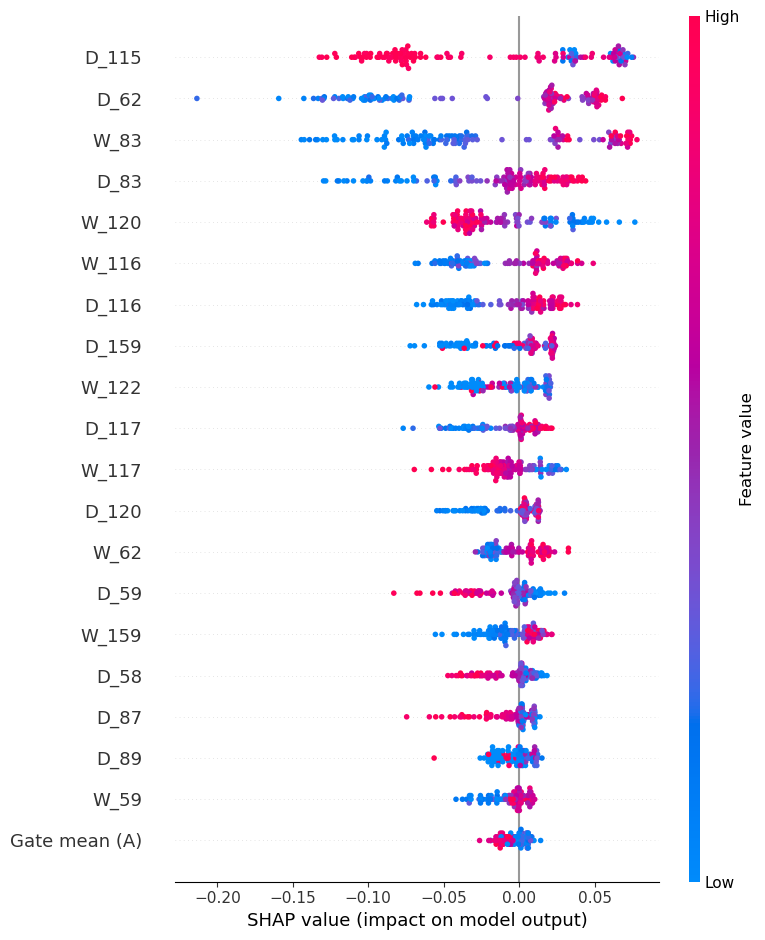

In [72]:
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

sv = shap_values[:, :, 1]

shap.summary_plot(sv, X, feature_names=feature_cols, max_display=20, show=False)

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
plt.savefig(os.path.join(path, "ML", f"filtered_DW_RF_shap_summary_{len(y)}samples.png"), dpi=300, bbox_inches='tight')
plt.show()

## Multiclass Classification
Testing the Random Forest as a 4-class model: **Binder**, **False Positive**, **Low Confidence**, **Fail Geometry**.

In [82]:
# -------------------------------------------------------------------
# Multiclass labels
# Adjust column name below if your sheet uses a different header
# -------------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, classification_report, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_predict

GROUP_COL = "Group"  # <-- change if needed

le = LabelEncoder()
y_mc = le.fit_transform(df[GROUP_COL].values)
class_names = le.classes_

print("Classes:", list(class_names))
print("Class distribution:")
for cls, encoded in zip(class_names, range(len(class_names))):
    print(f"  {cls}: {(y_mc == encoded).sum()}")
print(f"  Total: {len(y_mc)}")


Classes: ['binder', 'fail_gate', 'low_pkt', 'nonbinder']
Class distribution:
  binder: 37
  fail_gate: 10
  low_pkt: 9
  nonbinder: 74
  Total: 130


In [83]:
# -------------------------------------------------------------------
# Multiclass RF + stratified CV
# -------------------------------------------------------------------
from sklearn.metrics import make_scorer

rf_mc = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
)

scoring_mc = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc_ovr",          # one-vs-rest, uses predict_proba
    "f1":                make_scorer(f1_score,        average="macro", zero_division=0),
    "precision":         make_scorer(precision_score, average="macro", zero_division=0),
    "recall":            make_scorer(recall_score,    average="macro", zero_division=0),
}

cv_mc = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_mc_results = cross_validate(
    rf_mc, X, y_mc, cv=cv_mc,
    scoring=scoring_mc,
    return_train_score=False,
)

metrics_mc = {k.replace("test_", ""): v for k, v in cv_mc_results.items()
              if k.startswith("test_")}

print(f"--- {N_SPLITS}-fold stratified CV (multiclass, balanced RF) ---")
mc_df = pd.DataFrame({
    k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
    for k, v in metrics_mc.items()
}).T
print(mc_df.to_string())


--- 7-fold stratified CV (multiclass, balanced RF) ---
                    Mean     SD
accuracy           0.731  0.050
balanced_accuracy  0.409  0.033
roc_auc            0.883  0.083
f1                 0.387  0.031
precision          0.381  0.032
recall             0.409  0.033


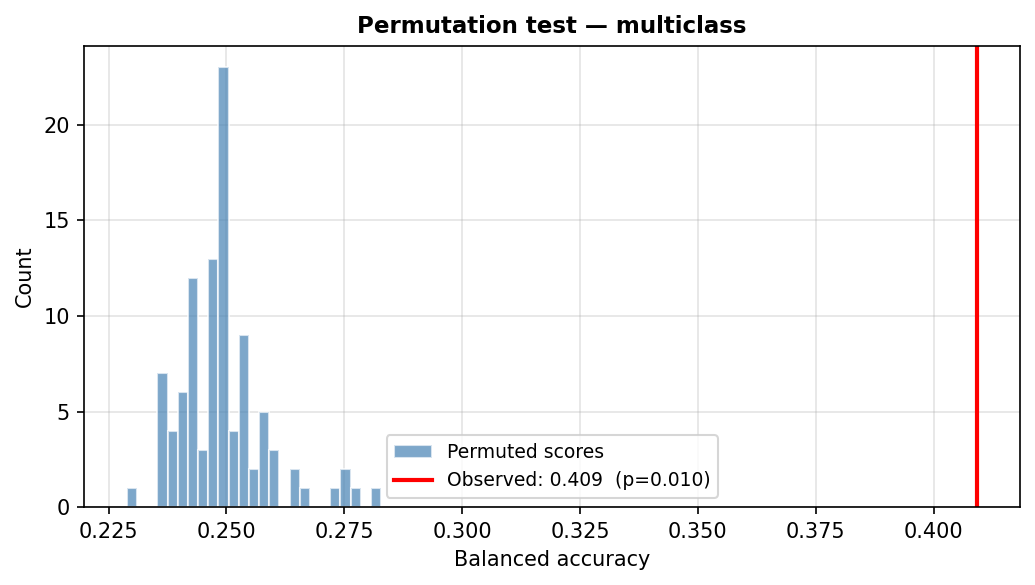

Multiclass permutation test  |  Observed balanced accuracy: 0.409  |  p-value: 0.010


In [84]:
# -------------------------------------------------------------------
# Permutation test (multiclass, balanced accuracy)
# -------------------------------------------------------------------
score_mc, perm_scores_mc, pval_mc = permutation_test_score(
    rf_mc, X, y_mc, cv=cv_mc, scoring="balanced_accuracy",
    n_permutations=100, random_state=42, n_jobs=1,
)

fig_pm, ax_pm = plt.subplots(figsize=(7, 4), dpi=150)
ax_pm.hist(perm_scores_mc, bins=25, color="steelblue", alpha=0.7, edgecolor="white",
           label="Permuted scores")
ax_pm.axvline(score_mc, color="red", lw=2,
              label=f"Observed: {score_mc:.3f}  (p={pval_mc:.3f})")
ax_pm.set_xlabel("Balanced accuracy", fontsize=10)
ax_pm.set_ylabel("Count", fontsize=10)
ax_pm.set_title("Permutation test — multiclass", fontsize=11, fontweight="bold")
ax_pm.legend(fontsize=9)
ax_pm.grid(True, alpha=0.35)
ax_pm.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Multiclass permutation test  |  Observed balanced accuracy: {score_mc:.3f}  |  p-value: {pval_mc:.3f}")


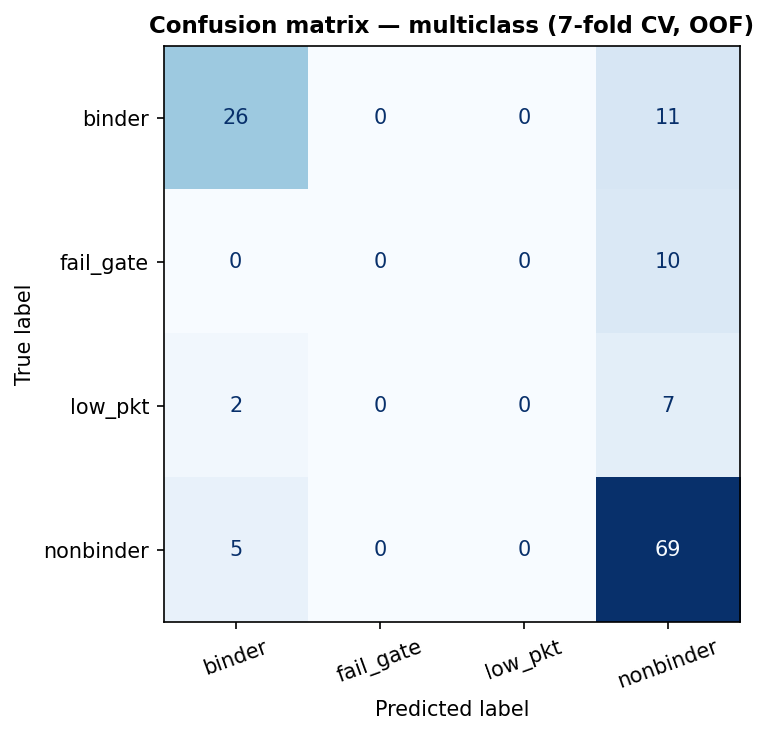

--- Classification report (multiclass, OOF) ---
              precision    recall  f1-score   support

      binder       0.79      0.70      0.74        37
   fail_gate       0.00      0.00      0.00        10
     low_pkt       0.00      0.00      0.00         9
   nonbinder       0.71      0.93      0.81        74

    accuracy                           0.73       130
   macro avg       0.37      0.41      0.39       130
weighted avg       0.63      0.73      0.67       130



In [85]:
# -------------------------------------------------------------------
# Confusion matrix (4-class, OOF predictions)
# -------------------------------------------------------------------
y_pred_mc_cv = cross_val_predict(rf_mc, X, y_mc, cv=cv_mc)

fig_cm, ax_cm = plt.subplots(figsize=(6, 5), dpi=150)
cm_mc = confusion_matrix(y_mc, y_pred_mc_cv)
disp_mc = ConfusionMatrixDisplay(cm_mc, display_labels=class_names)
disp_mc.plot(ax=ax_cm, colorbar=False, cmap="Blues",
             xticks_rotation=20)
ax_cm.set_title(f"Confusion matrix — multiclass ({N_SPLITS}-fold CV, OOF)",
                fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_cm.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_confusion_matrix_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")

print("--- Classification report (multiclass, OOF) ---")
print(classification_report(y_mc, y_pred_mc_cv, target_names=class_names, zero_division=0))


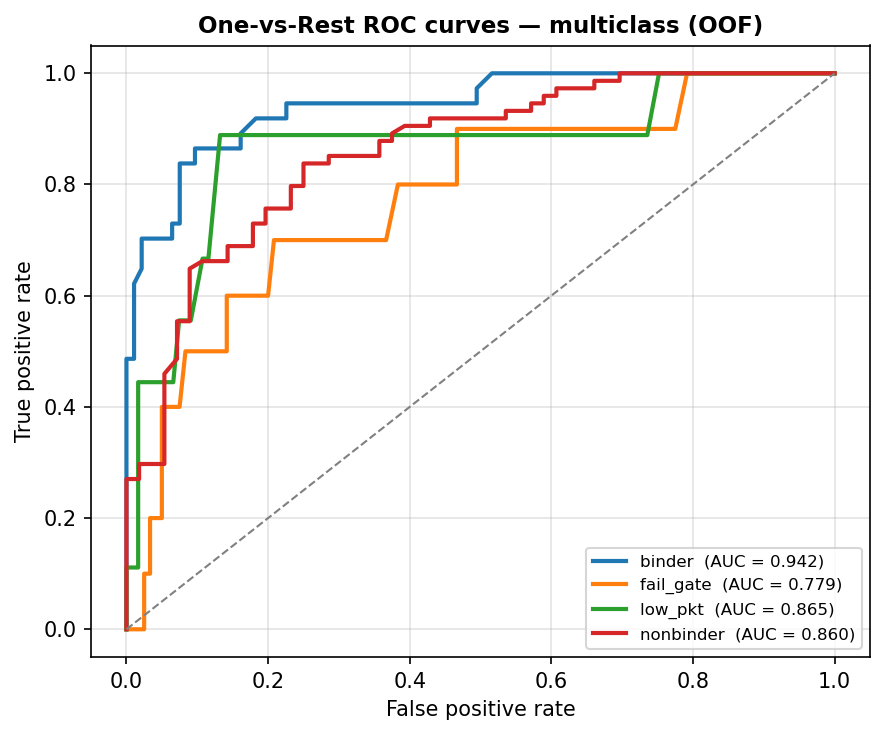

In [86]:
# -------------------------------------------------------------------
# One-vs-Rest ROC curves per class
# -------------------------------------------------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# OOF probability estimates for each class
y_prob_mc_cv = cross_val_predict(rf_mc, X, y_mc, cv=cv_mc, method="predict_proba")

# Binarize true labels for OvR evaluation
y_mc_bin = label_binarize(y_mc, classes=np.arange(len(class_names)))

# Group colors matching project palette
palette = {
    'Binder':         '#648FFF',   # blue
    'False Positive': '#DC267F',   # magenta
    'Low Confidence': '#FE6100',   # orange
    'Fail Geometry':  '#FFB000',   # gold
}

fig_roc, ax_roc = plt.subplots(figsize=(6, 5), dpi=150)

for i, cls in enumerate(class_names):
    fpr_i, tpr_i, _ = roc_curve(y_mc_bin[:, i], y_prob_mc_cv[:, i])
    roc_auc_i = auc(fpr_i, tpr_i)
    color = palette.get(cls, None)
    ax_roc.plot(fpr_i, tpr_i, lw=2, color=color,
                label=f"{cls}  (AUC = {roc_auc_i:.3f})")

ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax_roc.set_xlabel("False positive rate", fontsize=10)
ax_roc.set_ylabel("True positive rate", fontsize=10)
ax_roc.set_title("One-vs-Rest ROC curves — multiclass (OOF)",
                 fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8, loc="lower right")
ax_roc.grid(True, alpha=0.35)
ax_roc.set_axisbelow(True)
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_roc.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_ROC-AUC_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")


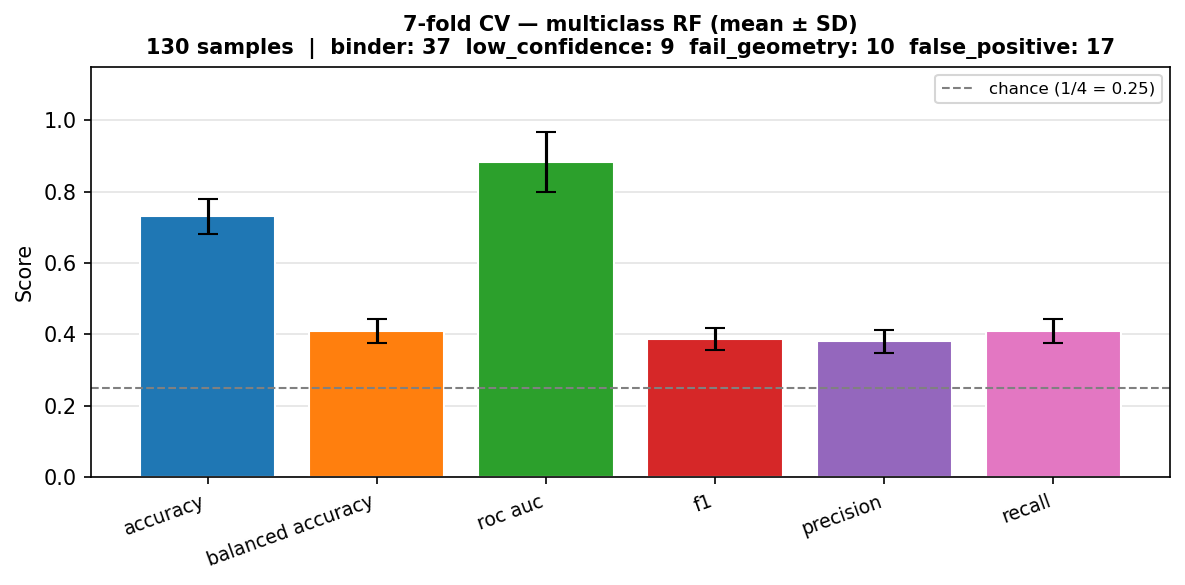

In [87]:
# -------------------------------------------------------------------
# CV metric bar chart — multiclass (matches binary metric set)
# -------------------------------------------------------------------
fig_mc_bar, ax_mc_bar = plt.subplots(figsize=(8, 4), dpi=150)

# Use same display order as binary model
metric_order = ["accuracy", "balanced_accuracy", "roc_auc", "f1", "precision", "recall"]
mc_metric_names = [m for m in metric_order if m in metrics_mc]

mc_means = [metrics_mc[m].mean() for m in mc_metric_names]
mc_sds   = [metrics_mc[m].std()  for m in mc_metric_names]
x_mc     = np.arange(len(mc_metric_names))

ax_mc_bar.bar(x_mc, mc_means, yerr=mc_sds, capsize=5,
              color=plt.get_cmap("tab10")(np.linspace(0, 0.6, len(mc_metric_names))),
              edgecolor="white")
ax_mc_bar.set_xticks(x_mc)
ax_mc_bar.set_xticklabels(
    [m.replace("_", " ") for m in mc_metric_names], rotation=20, ha="right", fontsize=9)
ax_mc_bar.set_ylabel("Score", fontsize=10)
ax_mc_bar.set_ylim(0, 1.15)
n_classes = len(class_names)
ax_mc_bar.axhline(1/n_classes, color="gray", linestyle="--", lw=1,
                  label=f"chance (1/{n_classes} = {1/n_classes:.2f})")
ax_mc_bar.set_title(
    f"{N_SPLITS}-fold CV — multiclass RF (mean ± SD)\n"
    f"{len(y_mc)} samples  |  binder: 37  low_confidence: 9  fail_geometry: 10  false_positive: 17",
    fontsize=10, fontweight="bold")
ax_mc_bar.legend(fontsize=8)
ax_mc_bar.grid(True, axis="y", alpha=0.35)
ax_mc_bar.set_axisbelow(True)
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_mc_bar.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")